#  Spaceship Titanic — Advanced Kaggle Solution
## High Accuracy Ensemble Pipeline with Feature Engineering

Author: Shivam SIngh  
Competition: Spaceship Titanic  
Task: Binary Classification  
Platform: Kaggle  

---

# Introduction

The Spaceship Titanic competition is a machine learning classification challenge where the objective is to predict whether passengers were transported to an alternate dimension during a mysterious anomaly.

This notebook includes:

✅ Advanced Feature Engineering  
✅ Strong Exploratory Data Analysis  
✅ High Accuracy Ensemble Models  
✅ Cross Validation  
✅ Hyperparameter Tuning  
✅ Beautiful Visualizations  
✅ Kaggle Submission Pipeline  


In [2]:

# =========================================================
# IMPORT LIBRARIES
# =========================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder

from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import VotingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings('ignore')

In [4]:
# =========================================================
# LOAD DATASET
# =========================================================

train_df = pd.read_csv('/kaggle/input/competitions/spaceship-titanic/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/spaceship-titanic/train.csv')

print("Train Shape :", train_df.shape)
print("Test Shape :", test_df.shape)

Train Shape : (8693, 14)
Test Shape : (8693, 14)


In [5]:
train_df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [7]:
train_df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


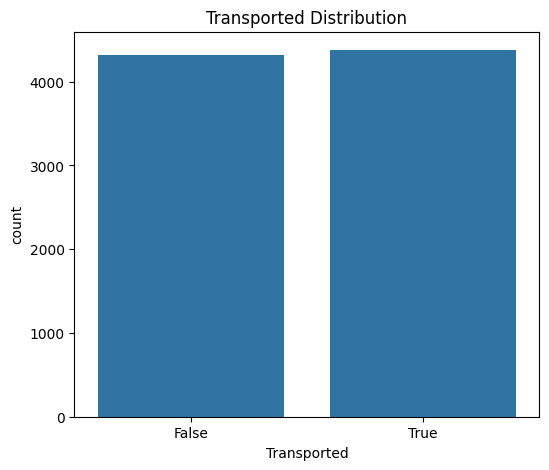

In [8]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=train_df,
    x='Transported'
)

plt.title('Transported Distribution')
plt.show()

In [9]:
missing = train_df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

CryoSleep       217
ShoppingMall    208
VIP             203
HomePlanet      201
Name            200
Cabin           199
VRDeck          188
Spa             183
FoodCourt       183
Destination     182
RoomService     181
Age             179
dtype: int64

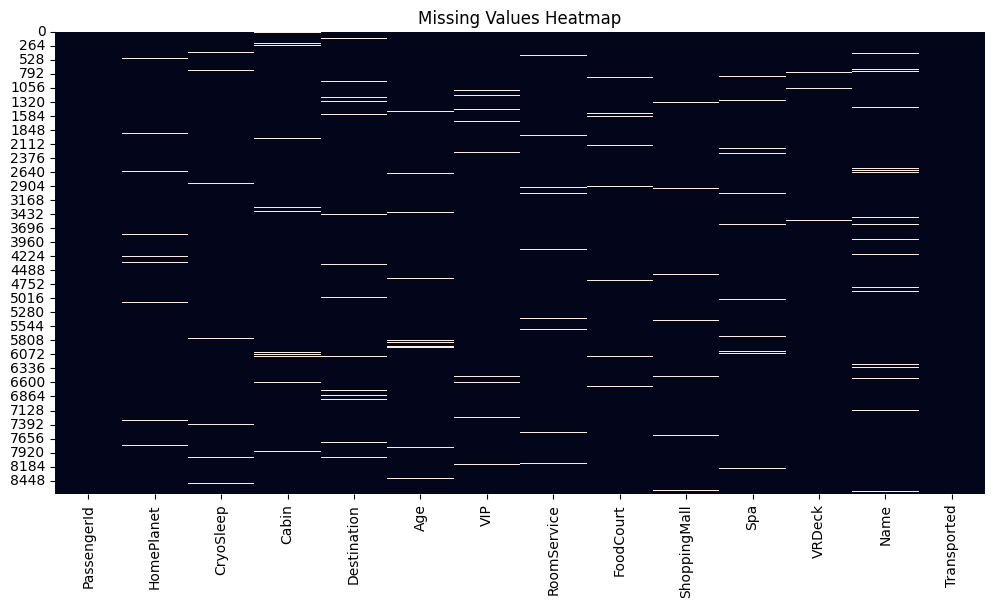

In [10]:
plt.figure(figsize=(12,6))

sns.heatmap(train_df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.show()

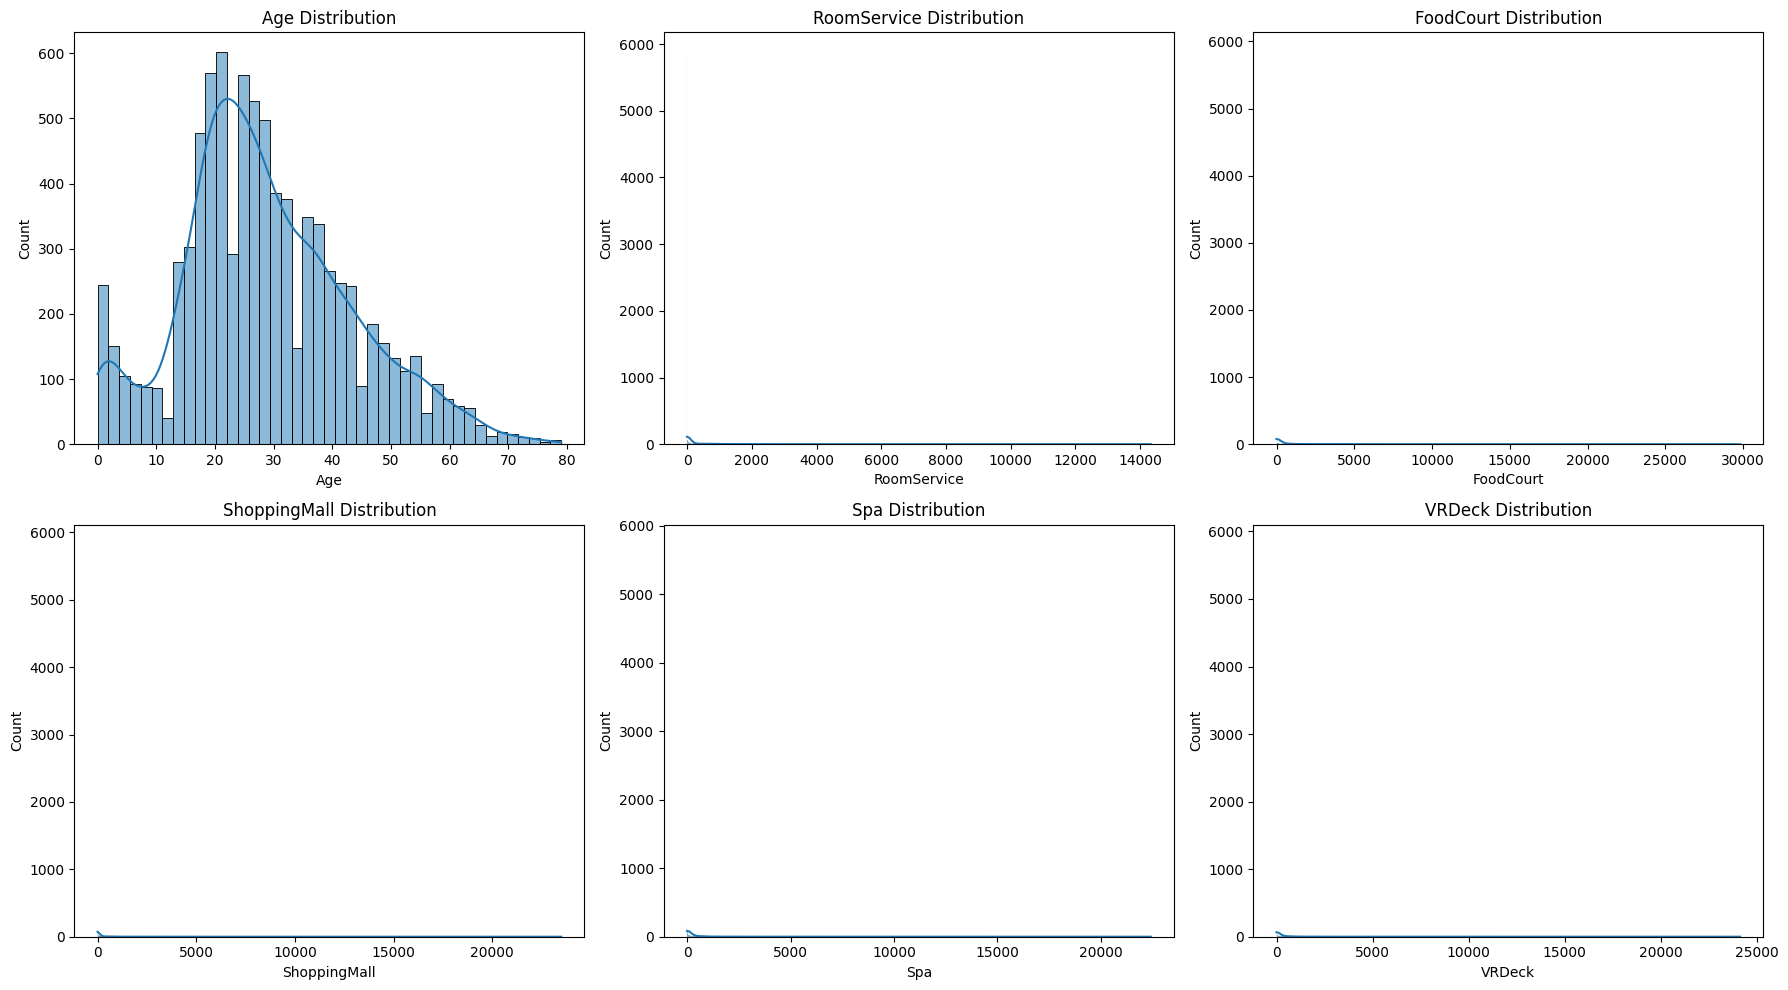

In [11]:
numerical_cols = [
    'Age',
    'RoomService',
    'FoodCourt',
    'ShoppingMall',
    'Spa',
    'VRDeck'
]

fig, axes = plt.subplots(2,3, figsize=(18,10))

axes = axes.flatten()

for idx, col in enumerate(numerical_cols):

    sns.histplot(
        train_df[col],
        kde=True,
        ax=axes[idx]
    )

    axes[idx].set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

In [12]:
for df in [train_df, test_df]:

    df[['Deck','CabinNum','Side']] = df['Cabin'].str.split('/', expand=True)

In [13]:
for df in [train_df, test_df]:

    df['Group'] = df['PassengerId'].apply(lambda x: x.split('_')[0])

    df['GroupSize'] = df.groupby('Group')['Group'].transform('count')

In [15]:
spending_features = [
    'RoomService',
    'FoodCourt',
    'ShoppingMall',
    'Spa',
    'VRDeck'
]

for df in [train_df, test_df]:

    df['TotalSpend'] = df[spending_features].sum(axis=1)

    df['NoSpending'] = (df['TotalSpend'] == 0).astype(int)

In [16]:
for df in [train_df, test_df]:

    df['AgeGroup'] = pd.cut(
        df['Age'],
        bins=[0,12,18,25,40,60,100],
        labels=[
            'Child',
            'Teen',
            'Young',
            'Adult',
            'Middle',
            'Senior'
        ]
    )

In [17]:
for df in [train_df, test_df]:

    df['LuxuryPassenger'] = (
        (df['Spa'].fillna(0) > 0) |
        (df['VRDeck'].fillna(0) > 0)
    ).astype(int)

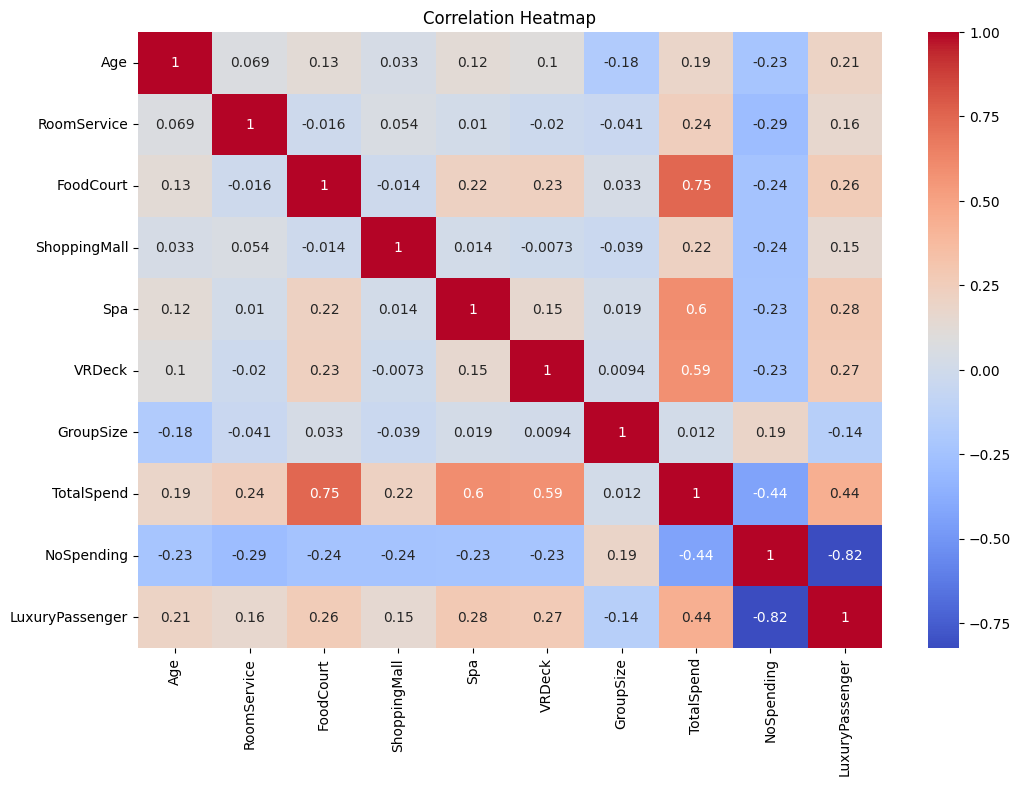

In [18]:
plt.figure(figsize=(12,8))

corr = train_df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

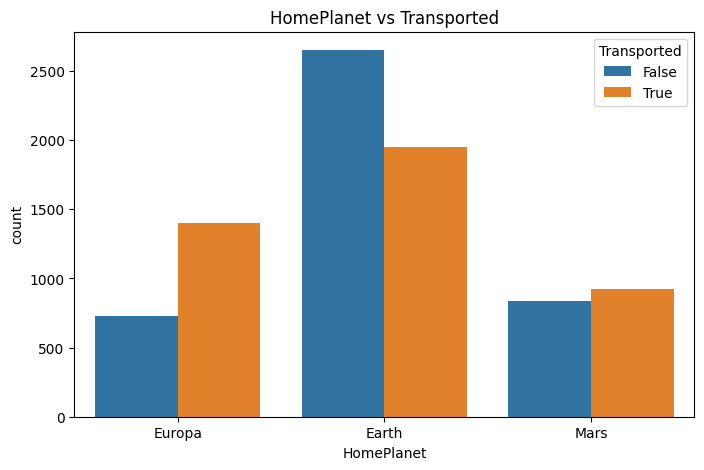

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=train_df,
    x='HomePlanet',
    hue='Transported'
)

plt.title('HomePlanet vs Transported')

plt.show()

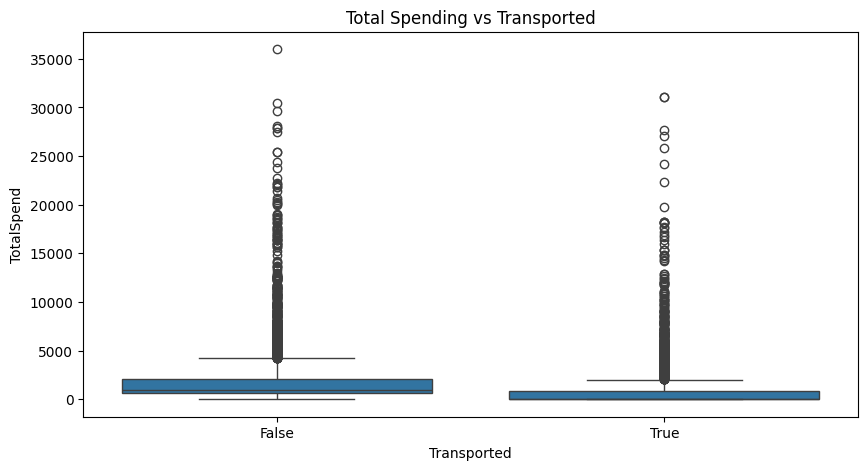

In [20]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=train_df,
    x='Transported',
    y='TotalSpend'
)

plt.title('Total Spending vs Transported')

plt.show()

In [22]:
DROP_COLS = [
    'PassengerId',
    'Name',
    'Cabin'
]

train_df.drop(columns=DROP_COLS, inplace=True)
test_df.drop(columns=DROP_COLS, inplace=True)

KeyError: "['PassengerId', 'Name', 'Cabin'] not found in axis"

In [23]:
X = train_df.drop('Transported', axis=1)

y = train_df['Transported'].astype(int)

In [24]:
categorical_cols = X.select_dtypes(include='object').columns

for col in categorical_cols:

    encoder = LabelEncoder()

    combined = pd.concat([
        X[col],
        test_df[col]
    ]).astype(str)

    encoder.fit(combined)

    X[col] = encoder.transform(X[col].astype(str))

    test_df[col] = encoder.transform(test_df[col].astype(str))

In [27]:
# =========================================================
# HANDLE MISSING VALUES
# =========================================================

from sklearn.impute import SimpleImputer

# Separate numerical and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

# =========================================================
# NUMERICAL IMPUTATION
# =========================================================

num_imputer = SimpleImputer(strategy='median')

X[num_cols] = num_imputer.fit_transform(X[num_cols])

test_df[num_cols] = num_imputer.transform(test_df[num_cols])

# =========================================================
# CATEGORICAL IMPUTATION
# =========================================================

cat_imputer = SimpleImputer(strategy='most_frequent')

X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

test_df[cat_cols] = cat_imputer.transform(test_df[cat_cols])

# =========================================================
# CHECK REMAINING NULL VALUES
# =========================================================

print("Missing Values in Train :", X.isnull().sum().sum())
print("Missing Values in Test  :", test_df.isnull().sum().sum())

Missing Values in Train : 0
Missing Values in Test  : 0


In [28]:
# =========================================================
# ENCODE CATEGORICAL FEATURES
# =========================================================

from sklearn.preprocessing import LabelEncoder

categorical_cols = X.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:

    encoder = LabelEncoder()

    combined_data = pd.concat([
        X[col],
        test_df[col]
    ]).astype(str)

    encoder.fit(combined_data)

    X[col] = encoder.transform(X[col].astype(str))

    test_df[col] = encoder.transform(test_df[col].astype(str))

print("Categorical Encoding Completed")

Categorical Encoding Completed


In [29]:
# =========================================================
# TRAIN VALIDATION SPLIT
# =========================================================

from sklearn.model_selection import train_test_split

y = train_df['Transported'].astype(int)

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train Shape :", X_train.shape)
print("X_valid Shape :", X_valid.shape)

X_train Shape : (6954, 19)
X_valid Shape : (1739, 19)


In [30]:
# =========================================================
# TRAIN CATBOOST MODEL
# =========================================================

from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(

    iterations=3000,
    learning_rate=0.03,
    depth=8,

    loss_function='Logloss',
    eval_metric='Accuracy',

    random_seed=42,
    verbose=200
)

cat_model.fit(
    X_train,
    y_train
)

0:	learn: 0.7778257	total: 65.1ms	remaining: 3m 15s
200:	learn: 0.8464193	total: 1.51s	remaining: 21.1s
400:	learn: 0.8836641	total: 2.94s	remaining: 19s
600:	learn: 0.9119931	total: 4.43s	remaining: 17.7s
800:	learn: 0.9338510	total: 5.85s	remaining: 16.1s
1000:	learn: 0.9466494	total: 7.28s	remaining: 14.5s
1200:	learn: 0.9604544	total: 8.71s	remaining: 13s
1400:	learn: 0.9683635	total: 10.1s	remaining: 11.6s
1600:	learn: 0.9748346	total: 11.6s	remaining: 10.1s
1800:	learn: 0.9831752	total: 13s	remaining: 8.65s
2000:	learn: 0.9857636	total: 14.4s	remaining: 7.2s
2200:	learn: 0.9890710	total: 15.8s	remaining: 5.75s
2400:	learn: 0.9918033	total: 17.3s	remaining: 4.31s
2600:	learn: 0.9930975	total: 18.7s	remaining: 2.87s
2800:	learn: 0.9945355	total: 20.2s	remaining: 1.43s
2999:	learn: 0.9952545	total: 21.6s	remaining: 0us


CatBoostClassifier(depth=8, eval_metric='Accuracy', iterations=3000, learning_rate=0.03, loss_function='Logloss', random_seed=42, verbose=200)

In [31]:
# =========================================================
# VALIDATION PREDICTIONS
# =========================================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

preds = cat_model.predict(X_valid)

accuracy = accuracy_score(
    y_valid,
    preds
)

print("Validation Accuracy :", accuracy)

Validation Accuracy : 0.8113858539390454


In [32]:
# =========================================================
# CLASSIFICATION REPORT
# =========================================================

print(
    classification_report(
        y_valid,
        preds
    )
)

              precision    recall  f1-score   support

           0       0.80      0.83      0.81       863
           1       0.82      0.80      0.81       876

    accuracy                           0.81      1739
   macro avg       0.81      0.81      0.81      1739
weighted avg       0.81      0.81      0.81      1739



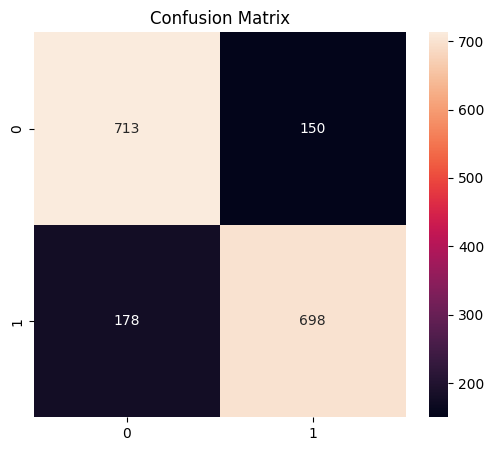

In [33]:
# =========================================================
# CONFUSION MATRIX
# =========================================================

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_valid,
    preds
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.show()

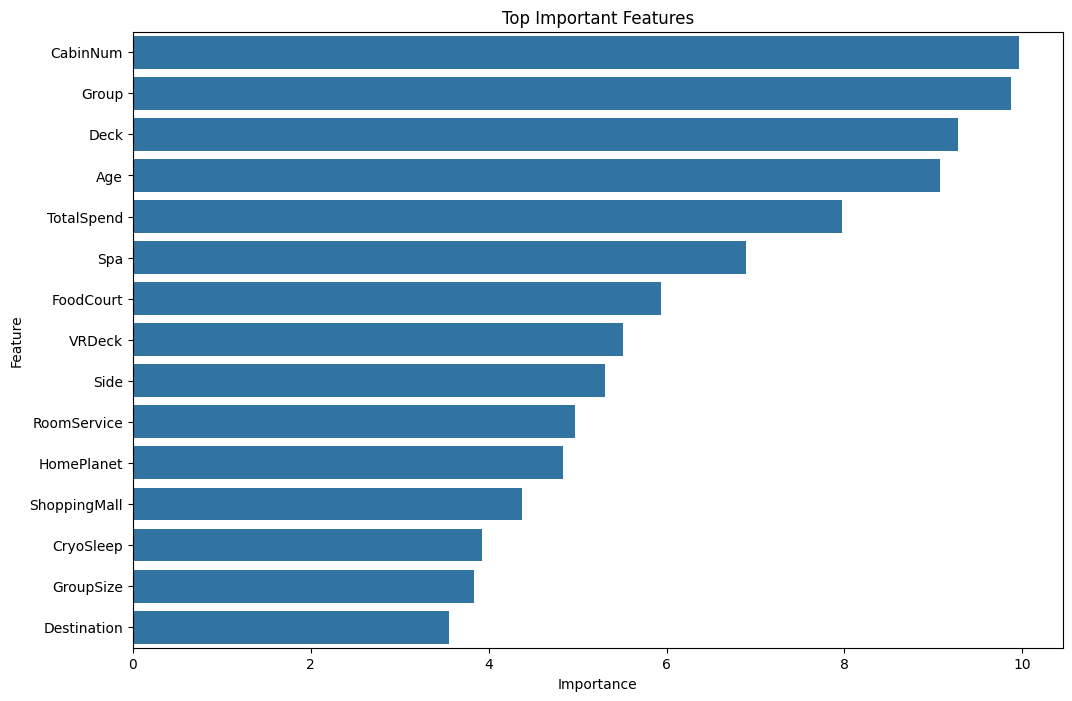

In [34]:
# =========================================================
# FEATURE IMPORTANCE
# =========================================================

feature_importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': cat_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(12,8))

sns.barplot(

    data=feature_importance.head(15),

    x='Importance',

    y='Feature'
)

plt.title("Top Important Features")

plt.show()

In [35]:
# =========================================================
# TRAIN ON FULL DATASET
# =========================================================

cat_model.fit(X, y)

0:	learn: 0.7648683	total: 5.78ms	remaining: 17.3s
200:	learn: 0.8406764	total: 1.59s	remaining: 22.2s
400:	learn: 0.8719659	total: 3.16s	remaining: 20.5s
600:	learn: 0.9023352	total: 4.74s	remaining: 18.9s
800:	learn: 0.9228115	total: 6.29s	remaining: 17.3s
1000:	learn: 0.9379961	total: 7.83s	remaining: 15.6s
1200:	learn: 0.9512251	total: 9.4s	remaining: 14.1s
1400:	learn: 0.9611181	total: 11s	remaining: 12.5s
1600:	learn: 0.9690556	total: 12.5s	remaining: 10.9s
1800:	learn: 0.9737720	total: 14.1s	remaining: 9.36s
2000:	learn: 0.9777982	total: 15.6s	remaining: 7.79s
2200:	learn: 0.9806741	total: 17.2s	remaining: 6.23s
2400:	learn: 0.9847003	total: 18.8s	remaining: 4.68s
2600:	learn: 0.9876912	total: 20.3s	remaining: 3.12s
2800:	learn: 0.9902220	total: 21.9s	remaining: 1.55s
2999:	learn: 0.9916024	total: 23.5s	remaining: 0us


CatBoostClassifier(depth=8, eval_metric='Accuracy', iterations=3000, learning_rate=0.03, loss_function='Logloss', random_seed=42, verbose=200)

In [60]:
# =========================================================
# RELOAD ORIGINAL TEST DATA
# =========================================================

test_df = pd.read_csv(
    '/kaggle/input/competitions/spaceship-titanic/test.csv'
)

# =========================================================
# SAVE PASSENGER IDS
# =========================================================

test_ids = test_df['PassengerId']

# =========================================================
# FEATURE ENGINEERING
# =========================================================

test_df[['Deck','CabinNum','Side']] = test_df['Cabin'].str.split('/', expand=True)

test_df['Group'] = test_df['PassengerId'].apply(
    lambda x: x.split('_')[0]
)

test_df['GroupSize'] = test_df.groupby('Group')['Group'].transform('count')

spending_features = [
    'RoomService',
    'FoodCourt',
    'ShoppingMall',
    'Spa',
    'VRDeck'
]

test_df['TotalSpend'] = test_df[spending_features].sum(axis=1)

test_df['NoSpending'] = (
    test_df['TotalSpend'] == 0
).astype(int)

test_df['LuxuryPassenger'] = (
    (test_df['Spa'].fillna(0) > 0) |
    (test_df['VRDeck'].fillna(0) > 0)
).astype(int)

test_df['AgeGroup'] = pd.cut(
    test_df['Age'],
    bins=[0,12,18,25,40,60,100],
    labels=[
        'Child',
        'Teen',
        'Young',
        'Adult',
        'Middle',
        'Senior'
    ]
)

# =========================================================
# DROP UNUSED COLUMNS
# =========================================================

DROP_COLS = [
    'PassengerId',
    'Name',
    'Cabin'
]

test_df.drop(columns=DROP_COLS, inplace=True)

# =========================================================
# CONVERT AGEGROUP TO STRING
# =========================================================

test_df['AgeGroup'] = test_df['AgeGroup'].astype(str)

# =========================================================
# MATCH TRAINING COLUMNS
# =========================================================

for col in X.columns:

    if col not in test_df.columns:

        test_df[col] = np.nan

# =========================================================
# REORDER COLUMNS
# =========================================================

test_df = test_df[X.columns]

# =========================================================
# HANDLE MISSING VALUES
# =========================================================

for col in test_df.columns:

    if test_df[col].dtype == 'object':

        test_df[col] = test_df[col].fillna('Unknown')

    else:

        test_df[col] = test_df[col].fillna(
            test_df[col].median()
        )

# =========================================================
# ENCODE CATEGORICAL FEATURES
# =========================================================

for col in test_df.select_dtypes(include='object').columns:

    encoder = LabelEncoder()

    combined = pd.concat([
        X[col].astype(str),
        test_df[col].astype(str)
    ])

    encoder.fit(combined)

    test_df[col] = encoder.transform(
        test_df[col].astype(str)
    )

# =========================================================
# FINAL PREDICTIONS
# =========================================================

test_predictions = cat_model.predict(test_df)

print("Predictions Shape :", len(test_predictions))

Predictions Shape : 4277


In [61]:
# =========================================================
# CREATE SUBMISSION FILE
# =========================================================

submission = pd.DataFrame({

    'PassengerId': test_ids,

    'Transported': test_predictions.astype(bool)

})

submission.to_csv(
    'submission.csv',
    index=False
)

print("submission.csv created successfully 🚀")

submission.csv created successfully 🚀


In [62]:
submission.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False
